### Data Set : Vehicle/Driver Data

For the sake of simplicity, we will take only two features : mean distance driven per day and the mean percentage of time a driver was >5 mph over the speed limit.

Here are what the data represent:
* id: Unique Id of the driver .
* mean_dist_day: Mean distance driven by driver per day
* mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#### 2) Loading Data:

In [2]:
df = pd.read_csv('driver-data.csv')

In [3]:
df.head()

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


In [4]:
df.shape

(4000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [6]:
df.describe()

,id,mean_dist_day,mean_over_speed_perc
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


- "id" is unique for all the records, we can drop it.

In [7]:
df.drop('id', axis= 1, inplace= True)

In [8]:
df.head()

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


#### 3) Data Exploration and Transformation:

##### 1) mean_dist_day:

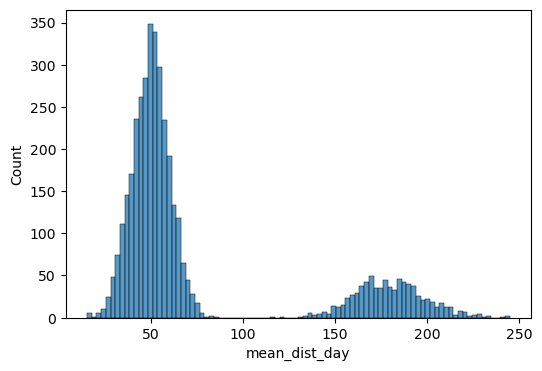

In [9]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'mean_dist_day')
plt.show()

- There are two distinctive distribution in Mean Distance Travelled per Day.
- Most drivers are centered around 50 miles per day and other group is centered around 175 miles per day.

##### 2) mean_over_speed_perc:

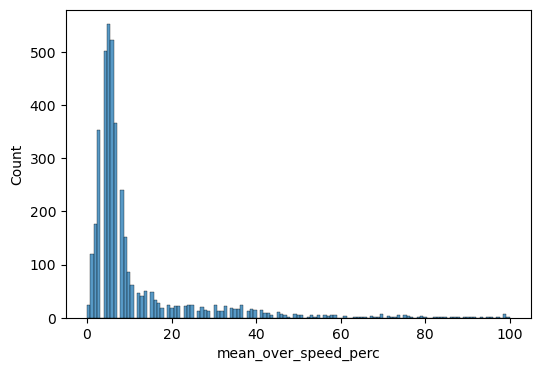

In [10]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'mean_over_speed_perc')
plt.show()

- Distribution is right tailed.
- For most the drivers, percentage of time they were over > 5 mph over speed limit is around 0-20.
- Some drivers are as far as 100% of time over > 5 mph over speed limit.

##### 3) Relations between Features:

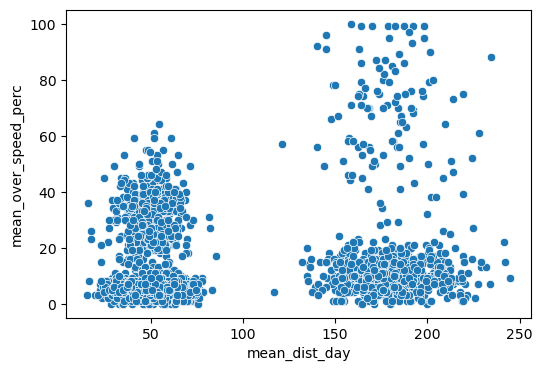

In [11]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'mean_dist_day', y= 'mean_over_speed_perc')
plt.show()